In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Завантаження даних
try:
    df_current = pd.read_csv('ab_test_task_data.csv')
    df_historical = pd.read_csv('ab_test_task_historical_data.csv')
    print("Файли успішно завантажено!")
except Exception as e:
    print(f"Помилка завантаження: {e}")

# 2. Функція для швидкого аналізу датасету
def inspect_data(df, name):
    print(f"\n--- Аналіз датасету: {name} ---")
    print(f"Розмірність: {df.shape}")
    print("\nТипи даних та пропуски:")
    print(df.info())
    print("\nКількість унікальних користувачів:", df['id_user'].nunique())
    print("\nПерші 3 рядки:")
    display(df.head(3))

# Перевіряємо обидва датасети
inspect_data(df_current, "Поточний А/В тест (df_current)")
inspect_data(df_historical, "Історичні дані (df_historical)")

# 3. Конвертація дат у формат datetime
date_cols_current = ['date_reg', 'date_first_payment', 'date_spent_15_credits', 'date_reminder']
date_cols_hist = ['date_reg', 'date_first_payment', 'date_spent_15_credits']

for col in date_cols_current:
    df_current[col] = pd.to_datetime(df_current[col], errors='coerce')

for col in date_cols_hist:
    df_historical[col] = pd.to_datetime(df_historical[col], errors='coerce')

print("\nДати успішно конвертовано у datetime.")

Файли успішно завантажено!

--- Аналіз датасету: Поточний А/В тест (df_current) ---
Розмірність: (125217, 6)

Типи даних та пропуски:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125217 entries, 0 to 125216
Data columns (total 6 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   id_user                125217 non-null  int64 
 1   date_reg               125217 non-null  object
 2   date_first_payment     7237 non-null    object
 3   date_spent_15_credits  51553 non-null   object
 4   date_reminder          15208 non-null   object
 5   match                  125217 non-null  int64 
dtypes: int64(2), object(4)
memory usage: 5.7+ MB
None

Кількість унікальних користувачів: 125217

Перші 3 рядки:


,id_user,date_reg,date_first_payment,date_spent_15_credits,date_reminder,match
0,1,2023-03-14 08:37:01.855460 UTC,2023-03-14 11:25:23.962741 UTC,2023-03-14 09:15:31.000000 UTC,2023-03-14 09:04:03.823970 UTC,1
1,2,2023-03-14 08:37:20.988023 UTC,NaN,NaN,NaN,0
2,3,2023-03-14 08:39:01.389639 UTC,NaN,2023-03-14 08:53:21.000000 UTC,2023-03-14 08:46:43.971330 UTC,0



--- Аналіз датасету: Історичні дані (df_historical) ---
Розмірність: (59758, 4)

Типи даних та пропуски:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59758 entries, 0 to 59757
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id_user                59758 non-null  int64 
 1   date_reg               59758 non-null  object
 2   date_first_payment     3257 non-null   object
 3   date_spent_15_credits  22268 non-null  object
dtypes: int64(1), object(3)
memory usage: 1.8+ MB
None

Кількість унікальних користувачів: 59758

Перші 3 рядки:


,id_user,date_reg,date_first_payment,date_spent_15_credits
0,1,2023-03-01 00:00:09.068945 UTC,2023-03-01 02:06:31.472018 UTC,2023-03-01 02:00:38.000000 UTC
1,2,2023-03-01 00:00:25.615471 UTC,NaN,2023-03-01 00:17:38.000000 UTC
2,3,2023-03-01 00:00:39.084989 UTC,2023-03-01 00:52:37.812217 UTC,2023-03-01 00:18:53.000000 UTC



Дати успішно конвертовано у datetime.


Базова конверсія (Baseline CR): 0.0545 (5.45%)

Статистика щоденних реєстрацій на історичних даних:
count       9.000000
mean     6639.777778
std       482.587758
min      5940.000000
25%      6324.000000
50%      6842.000000
75%      6895.000000
max      7321.000000
Name: id_user, dtype: float64


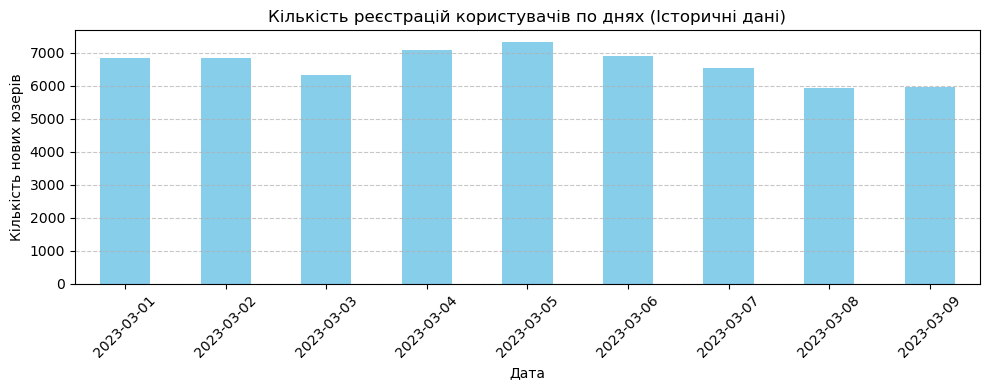

In [2]:
# 1. Розрахунок базової конверсії в історичних даних
historical_total_users = df_historical['id_user'].nunique()
historical_paying_users = df_historical['date_first_payment'].notna().sum()
baseline_conversion = historical_paying_users / historical_total_users

print(f"Базова конверсія (Baseline CR): {baseline_conversion:.4f} ({baseline_conversion * 100:.2f}%)")

# 2. Розрахунок швидкості реєстрації нових користувачів за день
# Витягуємо тільки дату (без часу) з реєстрації
df_historical['reg_date_only'] = df_historical['date_reg'].dt.date

# Групуємо по днях і рахуємо кількість реєстрацій
daily_registrations = df_historical.groupby('reg_date_only')['id_user'].count()

print("\nСтатистика щоденних реєстрацій на історичних даних:")
print(daily_registrations.describe())

# Візуалізуємо потік реєстрацій, щоб переконатися, що він стабільний
plt.figure(figsize=(10, 4))
daily_registrations.plot(kind='bar', color='skyblue')
plt.title('Кількість реєстрацій користувачів по днях (Історичні дані)')
plt.xlabel('Дата')
plt.ylabel('Кількість нових юзерів')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [3]:
import statsmodels.stats.api as sms

# Параметри для розрахунку
baseline_cr = 0.0545  # 5.45%
mde_relative = 0.10   # бажаємо помітити ріст на 10% від бази
mde_absolute = baseline_cr * mde_relative 

alpha = 0.05  # Рівень значущості (5%)
power = 0.80  # Потужність тесту (80%)

# 1. Розрахунок необхідної кількості користувачів на ОДНУ групу
effect_size = sms.proportion_effectsize(baseline_cr, baseline_cr + mde_absolute)
required_n_per_group = sms.NormalIndPower().solve_power(
    effect_size, 
    power=power, 
    alpha=alpha, 
    ratio=1
)

required_n_total = int(required_n_per_group * 2)
avg_daily_users = 6640
days_required = required_n_total / avg_daily_users

print(f"--- Розрахунок тривалості А/В тесту ---")
print(f"MDE (відносний): {mde_relative*100}%")
print(f"Необхідна сумарна кількість юзерів: {required_n_total}")
print(f"Середня кількість реєстрацій на день: {avg_daily_users}")
print(f"Необхідна тривалість тесту: {days_required:.2f} днів")

# Створимо табличку для різних варіантів MDE, щоб бути гнучкими
mdes = [0.05, 0.10, 0.15, 0.20]
results = []

for m in mdes:
    e_size = sms.proportion_effectsize(baseline_cr, baseline_cr * (1 + m))
    n = sms.NormalIndPower().solve_power(e_size, power=power, alpha=alpha, ratio=1)
    days = (n * 2) / avg_daily_users
    results.append({'MDE %': int(m*100), 'Total Users': int(n*2), 'Days': round(days, 1)})

df_power = pd.DataFrame(results)
print("\nТаблиця залежності тривалості від очікуваного ефекту:")
print(df_power)

--- Розрахунок тривалості А/В тесту ---
MDE (відносний): 10.0%
Необхідна сумарна кількість юзерів: 56994
Середня кількість реєстрацій на день: 6640
Необхідна тривалість тесту: 8.58 днів

Таблиця залежності тривалості від очікуваного ефекту:
   MDE %  Total Users  Days
0      5       222959  33.6
1     10        56994   8.6
2     15        25880   3.9
3     20        14862   2.2


In [4]:
from statsmodels.stats.proportion import proportions_ztest

# 1. Розділяємо дані на групи
control = df_current[df_current['match'] == 0]
test = df_current[df_current['match'] == 1]

# 2. Розрахунок основних показників
n_cnt = len(control)
n_tst = len(test)

pay_cnt = control['date_first_payment'].notna().sum()
pay_tst = test['date_first_payment'].notna().sum()

cr_cnt = pay_cnt / n_cnt
cr_tst = pay_tst / n_tst

# 3. Z-test для пропорцій
z_stat, p_val = proportions_ztest([pay_tst, pay_cnt], [n_tst, n_cnt])

print(f"--- Загальні результати А/В тесту ---")
print(f"Контроль (0): {n_cnt} юзерів, {pay_cnt} оплат, CR = {cr_cnt:.2%}")
print(f"Тест (1):    {n_tst} юзерів, {pay_tst} оплат, CR = {cr_tst:.2%}")
print(f"Відносна зміна CR: {((cr_tst - cr_cnt) / cr_cnt):.2%}")
print(f"p-value: {p_val:.4f}")

if p_val < 0.05:
    print("\nРЕЗУЛЬТАТ: Різниця СТАТИСТИЧНО ЗНАЧУЩА")
else:
    print("\nРЕЗУЛЬТАТ: Різниця НЕ є статистично значущою")

# 4. Аналіз тих, хто побачив нагадування (вузьке горлишко)
reminder_users = df_current[df_current['date_reminder'].notna()]
print(f"\n--- Аналіз сегменту з нагадуванням ---")
print(f"Всього побачили нагадування: {len(reminder_users)}")
print(f"Частка від усіх юзерів: {len(reminder_users)/len(df_current):.2%}")

--- Загальні результати А/В тесту ---
Контроль (0): 62568 юзерів, 3506 оплат, CR = 5.60%
Тест (1):    62649 юзерів, 3731 оплат, CR = 5.96%
Відносна зміна CR: 6.28%
p-value: 0.0076

РЕЗУЛЬТАТ: Різниця СТАТИСТИЧНО ЗНАЧУЩА

--- Аналіз сегменту з нагадуванням ---
Всього побачили нагадування: 15208
Частка від усіх юзерів: 12.15%


--- Аналіз цільового сегменту (Target Group) ---
Контроль (без нагадування): CR = 13.48%
Тест (з нагадуванням):      CR = 16.07%
Lift у цільовій групі:       19.26%

--- Швидкість конверсії (години від реєстрації) ---
Контроль: Медіана = 15.24 год
Тест:    Медіана = 16.47 год


C:\Users\User\AppData\Local\Temp\ipykernel_9008\4010448466.py:52: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot([speed_cnt.dropna(), speed_tst.dropna()],


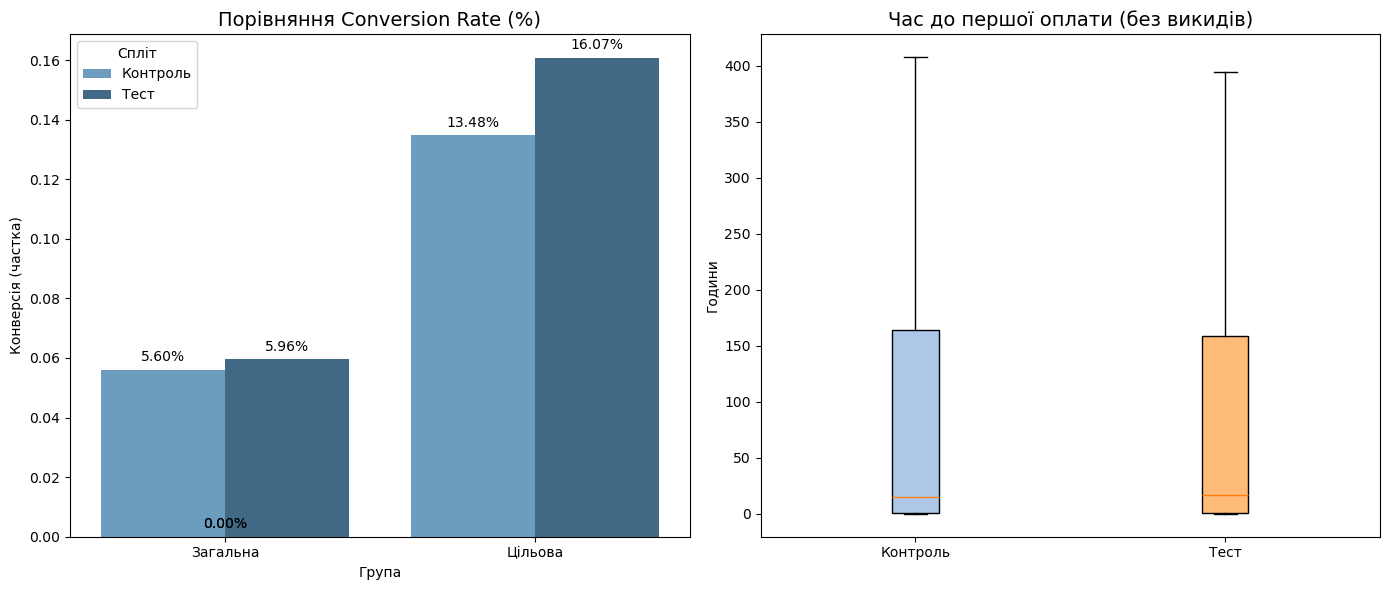

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Аналіз цільового сегменту (ті, хто витратив 15+ кредитів)
# Для контролю це наявність date_spent_15_credits
# Для тесту це наявність date_reminder (тригер спрацював)
reached_limit_cnt = control[control['date_spent_15_credits'].notna()].copy()
reached_limit_tst = test[test['date_reminder'].notna()].copy()

cr_limit_cnt = reached_limit_cnt['date_first_payment'].notna().mean()
cr_limit_tst = reached_limit_tst['date_first_payment'].notna().mean()

print(f"--- Аналіз цільового сегменту (Target Group) ---")
print(f"Контроль (без нагадування): CR = {cr_limit_cnt:.2%}")
print(f"Тест (з нагадуванням):      CR = {cr_limit_tst:.2%}")
print(f"Lift у цільовій групі:       {((cr_limit_tst - cr_limit_cnt) / cr_limit_cnt):.2%}")

# 2. Розрахунок швидкості оплати (години)
def calculate_speed(df):
    paid = df[df['date_first_payment'].notna()].copy()
    # Різниця в годинах
    return (paid['date_first_payment'] - paid['date_reg']).dt.total_seconds() / 3600

speed_cnt = calculate_speed(control)
speed_tst = calculate_speed(test)

print(f"\n--- Швидкість конверсії (години від реєстрації) ---")
print(f"Контроль: Медіана = {speed_cnt.median():.2f} год")
print(f"Тест:    Медіана = {speed_tst.median():.2f} год")

# 3. Візуалізація (оновлена та стабільна)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ГРАФІК 1: Порівняння CR (Загальний vs Цільовий сегмент)
# Підготуємо дані для зручної побудови
viz_data = pd.DataFrame({
    'Група': ['Загальна', 'Загальна', 'Цільова', 'Цільова'],
    'Спліт': ['Контроль', 'Тест', 'Контроль', 'Тест'],
    'CR': [cr_cnt, cr_tst, cr_limit_cnt, cr_limit_tst]
})

sns.barplot(data=viz_data, x='Група', y='CR', hue='Спліт', palette='Blues_d', ax=ax1)
ax1.set_title('Порівняння Conversion Rate (%)', fontsize=14)
ax1.set_ylabel('Конверсія (частка)')
for p in ax1.patches:
    ax1.annotate(f'{p.get_height():.2%}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 9), textcoords='offset points')

# ГРАФІК 2: Час до оплати (Boxplot)
# Використовуємо стандартний matplotlib для уникнення багів Seaborn
bp = ax2.boxplot([speed_cnt.dropna(), speed_tst.dropna()], 
            patch_artist=True, showfliers=False, labels=['Контроль', 'Тест'])

# Додамо кольорів боксплоту
colors = ['#aec7e8', '#ffbb78']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax2.set_title('Час до першої оплати (без викидів)', fontsize=14)
ax2.set_ylabel('Години')

plt.tight_layout()
plt.show()